In [ ]:
# 🔹 Step 1: Set dataset directory path
data_dir = "dataset" # ⬅️ Update this to your actual dataset path

# 🔹 Step 2: Import libraries
import tensorflow as tf
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.regularizers import l2

# 🔹 Step 3: Check GPU availability
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))
print("Available GPU(s):", tf.config.list_physical_devices('GPU'))

# 🔹 Step 4: Parameters
img_size = 224
batch_size = 32
input_shape = (img_size, img_size, 3)

# 🔹 Step 5: Load datasets using image_dataset_from_directory (No SciPy)
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_size, img_size),
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_size, img_size),
    batch_size=batch_size
)

# 🔹 Step 6: Prefetch for performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

# 🔹 Step 7: Optional - Add GPU-compatible augmentations
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomBrightness(0.2),
    tf.keras.layers.Rescaling(1./255)  # Normalize pixel values
])

train_ds = train_ds.map(lambda x, y: (data_augmentation(x), y))
val_ds = val_ds.map(lambda x, y: (tf.keras.layers.Rescaling(1./255)(x), y))

# 🔹 Step 8: Load DenseNet121 base model
base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=input_shape)

# 🔹 Step 9: Add custom classification head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)
x = Dense(512, activation='relu', kernel_regularizer=l2(0.001))(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)
x = Dense(256, activation='relu', kernel_regularizer=l2(0.001))(x)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)
x = Dense(128, activation='relu')(x)
predictions = Dense(train_ds.cardinality().numpy() if hasattr(train_ds, 'cardinality') else len(train_ds.class_names), activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

# 🔹 Step 10: Freeze base model
for layer in base_model.layers:
    layer.trainable = False

# 🔹 Step 11: Compile model
model.compile(optimizer=Adam(learning_rate=0.0003), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 🔹 Step 12: Define callbacks
checkpoint_path = "best_densenet_model.h5"

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', patience=3, factor=0.5, verbose=1)
checkpoint = ModelCheckpoint(filepath=checkpoint_path, monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)

# 🔹 Step 13: Initial training (top layers only)
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stop, reduce_lr, checkpoint]
)

# 🔹 Step 14: Unfreeze base model for fine-tuning
for layer in base_model.layers:
    layer.trainable = True

# 🔹 Step 15: Recompile for fine-tuning
model.compile(optimizer=Adam(learning_rate=1e-5), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 🔹 Step 16: Fine-tune full model
fine_tune_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stop, reduce_lr, checkpoint]
)


Num GPUs Available: 1
Available GPU(s): [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Found 124486 files belonging to 4 classes.
Using 99589 files for training.
Found 124486 files belonging to 4 classes.
Using 24897 files for validation.
Epoch 1/10
3113/3113 [==============================] - ETA: 0s - loss: 1.2130 - accuracy: 0.7385
Epoch 1: val_accuracy improved from -inf to 0.84829, saving model to best_densenet_model.h5
3113/3113 [==============================] - 491s 154ms/step - loss: 1.2130 - accuracy: 0.7385 - val_loss: 0.6922 - val_accuracy: 0.8483 - lr: 3.0000e-04
Epoch 2/10
3112/3113 [============================>.] - ETA: 0s - loss: 0.7282 - accuracy: 0.8133
Epoch 2: val_accuracy improved from 0.84829 to 0.86432, saving model to best_densenet_model.h5
3113/3113 [==============================] - 498s 160ms/step - loss: 0.7281 - accuracy: 0.8133 - val_loss: 0.5585 - val_accuracy: 0.8643 - lr: 3.0000e-04
Epoch 3/10
3112/3113 [============================

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Load model
model = tf.keras.models.load_model("best_densenet_model.h5")

# Reload dataset
data_dir = "dataset"
img_size = 224
batch_size = 32

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_size, img_size),
    batch_size=batch_size
)

class_names = val_ds.class_names

# Normalize images
val_ds = val_ds.map(lambda x, y: (tf.keras.layers.Rescaling(1./255)(x), y))


Found 124486 files belonging to 4 classes.
Using 24897 files for validation.


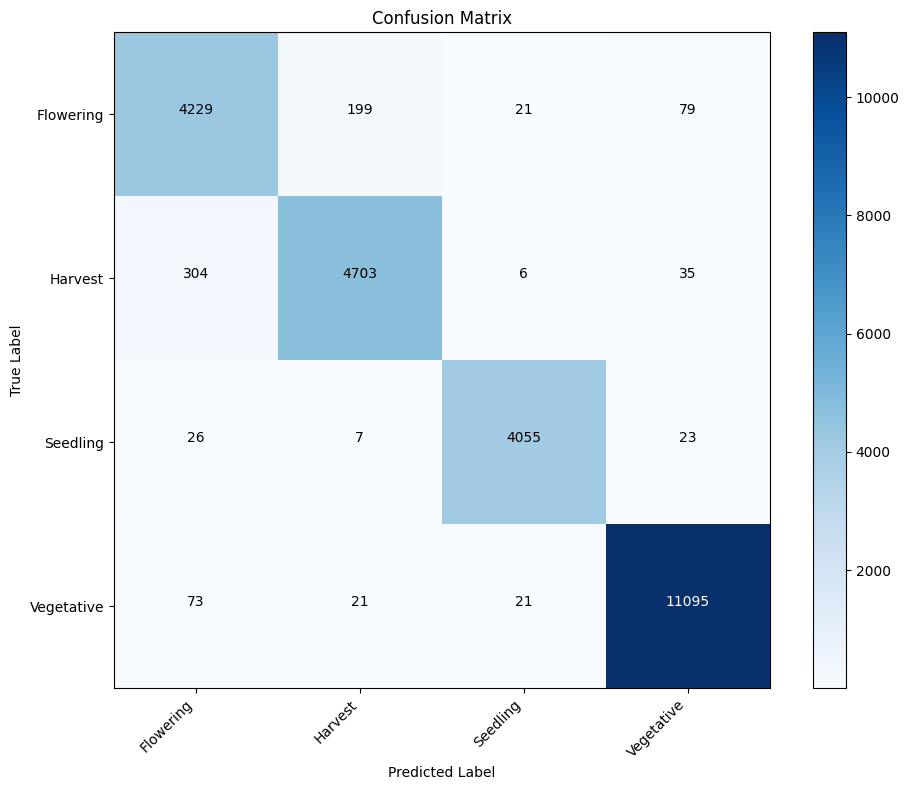

In [ ]:
# Collect predictions
y_true = []
y_pred = []

for images, labels in val_ds:
    predictions = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(tf.argmax(predictions, axis=1).numpy())

# Confusion matrix logic
num_classes = len(class_names)
conf_matrix = np.zeros((num_classes, num_classes), dtype=int)

for true, pred in zip(y_true, y_pred):
    conf_matrix[true][pred] += 1

# Plot confusion matrix
plt.figure(figsize=(10, 8))
plt.imshow(conf_matrix, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.colorbar()
tick_marks = np.arange(num_classes)
plt.xticks(tick_marks, class_names, rotation=45, ha='right')
plt.yticks(tick_marks, class_names)

thresh = conf_matrix.max() / 2
for i in range(num_classes):
    for j in range(num_classes):
        plt.text(j, i, str(conf_matrix[i, j]),
                 ha="center",
                 color="white" if conf_matrix[i, j] > thresh else "black")

plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np

# Assuming you already have this from your previous confusion matrix code
# conf_matrix: numpy array of shape [num_classes, num_classes]
# class_names: list of class names in order

# Initialize lists for metrics
precision_per_class = []
recall_per_class = []
f1_per_class = []
support_per_class = []

# Loop over each class index
for i in range(len(class_names)):
    TP = conf_matrix[i, i]
    FP = np.sum(conf_matrix[:, i]) - TP
    FN = np.sum(conf_matrix[i, :]) - TP
    support = np.sum(conf_matrix[i, :])  # actual class count

    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    precision_per_class.append(precision)
    recall_per_class.append(recall)
    f1_per_class.append(f1)
    support_per_class.append(support)

# Calculate macro-averages
macro_precision = np.mean(precision_per_class)
macro_recall = np.mean(recall_per_class)
macro_f1 = np.mean(f1_per_class)

# Overall accuracy
total_correct = np.trace(conf_matrix)
total_samples = np.sum(conf_matrix)
accuracy = total_correct / total_samples

# Print results
print("\n📊 Classification Report:")
for i, class_name in enumerate(class_names):
    print(f"{class_name:12} | Precision: {precision_per_class[i]:.4f} | Recall: {recall_per_class[i]:.4f} | F1-Score: {f1_per_class[i]:.4f} | Support: {support_per_class[i]}")

print("\n🔹 Overall Accuracy     :", f"{accuracy:.4f}")
print("🔹 Macro Precision      :", f"{macro_precision:.4f}")
print("🔹 Macro Recall         :", f"{macro_recall:.4f}")
print("🔹 Macro F1-Score       :", f"{macro_f1:.4f}")



📊 Classification Report:
Flowering    | Precision: 0.9130 | Recall: 0.9340 | F1-Score: 0.9234 | Support: 4528
Harvest      | Precision: 0.9540 | Recall: 0.9317 | F1-Score: 0.9427 | Support: 5048
Seedling     | Precision: 0.9883 | Recall: 0.9864 | F1-Score: 0.9873 | Support: 4111
Vegetative   | Precision: 0.9878 | Recall: 0.9897 | F1-Score: 0.9888 | Support: 11210

🔹 Overall Accuracy     : 0.9673
🔹 Macro Precision      : 0.9608
🔹 Macro Recall         : 0.9604
🔹 Macro F1-Score       : 0.9605


In [ ]:
# ✅ STEP 1: LOAD AND PREPARE MODEL FOR CONTINUED TRAINING

import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.optimizers import Adam

# Load the best previously saved model
model = load_model("best_densenet_model.h5")

# Unfreeze all layers to allow full fine-tuning
for layer in model.layers:
    layer.trainable = True

# Recompile with a low learning rate for fine-tuning
model.compile(optimizer=Adam(learning_rate=1e-5),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])


In [ ]:
# ✅ STEP 2: CONTINUE TRAINING FROM EPOCH 21 TO 50 (30 MORE EPOCHS)

# Reload dataset
img_size = 224
batch_size = 32
data_dir = "dataset"

# Reload datasets
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_size, img_size),
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_size, img_size),
    batch_size=batch_size
)

# Normalize & augment data
AUTOTUNE = tf.data.AUTOTUNE
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomBrightness(0.2),
    tf.keras.layers.Rescaling(1./255)
])
train_ds = train_ds.map(lambda x, y: (data_augmentation(x), y)).prefetch(AUTOTUNE)
val_ds = val_ds.map(lambda x, y: (tf.keras.layers.Rescaling(1./255)(x), y)).prefetch(AUTOTUNE)

# Callbacks
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

checkpoint = ModelCheckpoint("best_densenet_model_finetuned_50.h5",
                             monitor="val_accuracy",
                             save_best_only=True,
                             mode="max",
                             verbose=1)

early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor="val_loss", patience=3, factor=0.5, verbose=1)

# Run training for 30 more epochs
history_21_to_50 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,  # Continue from 21 to 50
    callbacks=[early_stop, reduce_lr, checkpoint]
)

# Optional: Print how many epochs actually ran
print("Epochs Trained (21–50):", len(history_21_to_50.history['loss']))


Found 124486 files belonging to 4 classes.
Using 99589 files for training.
Found 124486 files belonging to 4 classes.
Using 24897 files for validation.
Epoch 1/30
 191/3113 [>.............................] - ETA: 1:21:43 - loss: 0.1559 - accuracy: 0.9846

KeyboardInterrupt: 

In [ ]:
# ✅ STEP 2: CONTINUE TRAINING FROM EPOCH 21 TO 50 (30 MORE EPOCHS)

# Reload dataset
img_size = 224
batch_size = 32
data_dir = "dataset"

# Reload datasets
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_size, img_size),
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_size, img_size),
    batch_size=batch_size
)

# Normalize & augment data
AUTOTUNE = tf.data.AUTOTUNE
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomBrightness(0.2),
    tf.keras.layers.Rescaling(1./255)
])
train_ds = train_ds.map(lambda x, y: (data_augmentation(x), y)).prefetch(AUTOTUNE)
val_ds = val_ds.map(lambda x, y: (tf.keras.layers.Rescaling(1./255)(x), y)).prefetch(AUTOTUNE)

# Callbacks
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

checkpoint = ModelCheckpoint("best_densenet_model_finetuned_50.h5",
                             monitor="val_accuracy",
                             save_best_only=True,
                             mode="max",
                             verbose=1)

early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor="val_loss", patience=3, factor=0.5, verbose=1)

# ✅ Run training for 30 more epochs and display from epoch 21 to 50
history_21_to_50 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,             # final epoch number (end at 50)
    initial_epoch=20,      # start from epoch 21
    callbacks=[early_stop, reduce_lr, checkpoint]
)

# Print how many new epochs actually trained
print("Epochs Trained (21–50):", len(history_21_to_50.history['loss']))


Found 124486 files belonging to 4 classes.
Using 99589 files for training.
Found 124486 files belonging to 4 classes.
Using 24897 files for validation.
Epoch 21/50
3112/3113 [============================>.] - ETA: 0s - loss: 0.1201 - accuracy: 0.9921
Epoch 21: val_accuracy improved from -inf to 0.97068, saving model to best_densenet_model_finetuned_50.h5
3113/3113 [==============================] - 426s 137ms/step - loss: 0.1201 - accuracy: 0.9921 - val_loss: 0.1896 - val_accuracy: 0.9707 - lr: 1.0000e-05
Epoch 22/50
3112/3113 [============================>.] - ETA: 0s - loss: 0.1118 - accuracy: 0.9925
Epoch 22: val_accuracy improved from 0.97068 to 0.97104, saving model to best_densenet_model_finetuned_50.h5
3113/3113 [==============================] - 428s 137ms/step - loss: 0.1118 - accuracy: 0.9925 - val_loss: 0.1839 - val_accuracy: 0.9710 - lr: 1.0000e-05
Epoch 23/50
3112/3113 [============================>.] - ETA: 0s - loss: 0.1045 - accuracy: 0.9924
Epoch 23: val_accuracy did n

In [ ]:
# ✅ Continue training from epoch 51 to 100
history_51_to_100 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,            # final epoch number
    initial_epoch=50,      # resume from epoch 51
    callbacks=[early_stop, reduce_lr, checkpoint]
)

# Optional: Print how many epochs actually ran
print("Epochs Trained (51–100):", len(history_51_to_100.history['loss']))


Epoch 51/100
3112/3113 [============================>.] - ETA: 0s - loss: 0.0506 - accuracy: 0.9954
Epoch 51: val_accuracy did not improve from 0.97164
3113/3113 [==============================] - 420s 135ms/step - loss: 0.0506 - accuracy: 0.9954 - val_loss: 0.1540 - val_accuracy: 0.9715 - lr: 5.0000e-06
Epoch 52/100
3112/3113 [============================>.] - ETA: 0s - loss: 0.0498 - accuracy: 0.9953
Epoch 52: val_accuracy did not improve from 0.97164
3113/3113 [==============================] - 416s 133ms/step - loss: 0.0498 - accuracy: 0.9953 - val_loss: 0.1548 - val_accuracy: 0.9713 - lr: 5.0000e-06
Epoch 53/100
3112/3113 [============================>.] - ETA: 0s - loss: 0.0479 - accuracy: 0.9957
Epoch 53: val_accuracy did not improve from 0.97164
3113/3113 [==============================] - 417s 134ms/step - loss: 0.0479 - accuracy: 0.9957 - val_loss: 0.1559 - val_accuracy: 0.9711 - lr: 5.0000e-06
Epoch 54/100
3112/3113 [============================>.] - ETA: 0s - loss: 0.0467 -

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Get predictions and true labels
y_true = []
y_pred = []

for images, labels in val_ds:
    predictions = model.predict(images)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Step 2: Create confusion matrix (manual with NumPy)
num_classes = len(class_names)
confusion_mtx = np.zeros((num_classes, num_classes), dtype=int)

for true, pred in zip(y_true, y_pred):
    confusion_mtx[true][pred] += 1

print("Confusion Matrix:")
print(confusion_mtx)

# Step 3: Plot confusion matrix
plt.figure(figsize=(8, 6))
plt.imshow(confusion_mtx, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(num_classes)
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

# Annotate cells
thresh = confusion_mtx.max() / 2.
for i in range(num_classes):
    for j in range(num_classes):
        plt.text(j, i, str(confusion_mtx[i, j]),
                 ha="center", va="center",
                 color="white" if confusion_mtx[i, j] > thresh else "black")

plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.show()